In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

In [2]:
# load data (model)
res_savename_ext = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"

extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_gaps_v050426_v070426_geo"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_66248/1555084129.py:4: DtypeWarning: Columns (27,28,29,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))


In [3]:
#reformat output
labelled_df = format_output(labelled_df)
extracted_df = format_output(extracted_df)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)


In [18]:
labelled_df.quanti.value_counts()

quanti
quanti    361
quali     169
Name: count, dtype: int64

In [13]:
mask = extracted_df.apply(lambda x: any([haz for haz in x.hazards if haz in ["Unknown"]]), axis=1)
pd.DataFrame(extracted_df[mask])

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
11145,Economy and Livelihood,13.20,NaN,NaN,exact,%,"[Adding to the challenges, the inﬂation rate f...",1.0,[],"[Adding to the challenges, the inﬂation rate f...",...,0.0,[Mongolia],[Mongolia],[MNG],[256.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((87.75126 49.2972, 88.80557 49...."
15950,Affected People,204000.00,NaN,NaN,exact,people,"[204,000 17%]",0.0,[],"['IPC Information up to March 2024 2.', 'FAO A...",...,0.0,[Eswatini],[Eswatini],[SWZ],[123.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((32.07167 -26.73382, 31.86806 -..."
17522,Affected People,13.00,NaN,NaN,exact,provinces,[A total of 13 out of the 63 provinces of Viet...,0.0,"[Kien Giang, Tien Giang, Ben Tre, Long An, Ca ...",[A total of 13 out of the 63 provinces of Viet...,...,0.0,"[Bến Tre, Long An, Viet Nam, An Giang Province...","[Ben Tre, Long Dien, Viet Nam, An Giang, Tien ...",[VNM],[281.0],"[3211.0, 3206.0, nan, 3205.0, 3262.0]","[132979.0, 132941.0, nan]",NaN,False,"MULTIPOLYGON (((106.33147 10.27859, 106.33828 ..."
17534,Agriculture and Access to Food,31.12,NaN,NaN,exact,km**2 of crop production and forestry,"[Specifically, in Tra Vinh province, 3,112 hec...",0.0,[Tra Vinh province],"[Specifically, in Tra Vinh province, 3,112 hec...",...,0.0,[Trà Vinh],"[Tra Linh, Tra Vinh]",[VNM],[281.0],"[3218.0, 3263.0]","[133056.0, 133600.0]",NaN,False,"MULTIPOLYGON (((106.25145 22.8894, 106.25524 2..."


In [12]:
pd.DataFrame(extracted_df[extracted_df["appealCode"] == "MDRSZ004"])

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
15931,Affected People,268000.000000,NaN,NaN,exact,people,"[People Affected: 268,000 people]",0.0,"[Lubombo, Shiselweni]","[People Affected: 268,000 people, The regions ...",...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15932,Targeted People,30000.000000,NaN,NaN,exact,people,"[People Targeted: 30,000 people]",0.0,"[Lubombo, Shiselweni]","[People Targeted: 30,000 people, Targeted Area...",...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15933,DREF Allocation & Funding requirements,642310.906364,NaN,NaN,exact,EUR,"[DREF Allocation: CHF 599,533]",0.0,"[Lubombo, Shiselweni]","[DREF Allocation: CHF 599,533, Targeted Areas:...",...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15934,Affected People,238500.000000,NaN,NaN,exact,people,[The Integrated- Food Security Phase Classific...,0.0,[],[The Integrated- Food Security Phase Classific...,...,0.0,[Eswatini],[Eswatini],[SWZ],[123.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((32.07167 -26.73382, 31.86806 -..."
15935,Affected People,268000.000000,NaN,NaN,exact,people,"[From October 2023 to March 2024, it was proje...",0.0,"[Lubombo, Shiselweni]",[The regions with the highest prevalence of fo...,...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15936,Agriculture and Access to Food,25.000000,NaN,NaN,exact,% of the population,[25% of the population is concerned by the foo...,0.0,"[Lubombo, Shiselweni]",[The regions with the highest prevalence of fo...,...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15937,Agriculture and Access to Food,20.000000,NaN,NaN,exact,% of the population,[The Integrated- Food Security Phase Classific...,0.0,"[Lubombo, Shiselweni]",[The regions with the highest prevalence of fo...,...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15938,Agriculture and Access to Food,25.000000,NaN,NaN,exact,% of the population,[On average 25% will be facing acute food inse...,0.0,"[Lubombo, Shiselweni]",[The regions with the highest prevalence of fo...,...,0.0,"[Shiselweni, Lubombo]","[Shiselweni, Lubombo]",[SWZ],[123.0],"[1288.0, 1286.0]",[nan],NaN,False,"MULTIPOLYGON (((31.49334 -26.67813, 31.49395 -..."
15939,Affected People,25.000000,NaN,NaN,exact,% of population,[@IPC report 17.08.2023 Scope and Scale The 25...,0.0,[],[@IPC report 17.08.2023 Scope and Scale The 25...,...,0.0,[Eswatini],[Eswatini],[SWZ],[123.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((32.07167 -26.73382, 31.86806 -..."
15940,Affected People,30.000000,NaN,NaN,exact,% of population,[The IPC report further indicates that Dry Mid...,0.0,"[Dry Middleveld (DMV), Lowveld Cattle and Maiz...",[The IPC report further indicates that Dry Mid...,...,0.0,[Eswatini],[Eswatini],[SWZ],[123.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((32.07167 -26.73382, 31.86806 -..."


In [10]:
extracted_df.hazards.explode().value_counts()

hazards
Flood                       11809
Tropical storm               3591
Convective storm             3127
Drought                      1955
Mass movement                1564
Earthquake                   1307
Other storm                  1271
Epidemic                      871
Volcanic activity             642
Wildfire                      530
Extreme warm temperature      504
Extreme cold temperature      456
Conflict                      245
Wave action                   198
Unknown                         4
Name: count, dtype: int64

In [11]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                2708
Agriculture and Access to Food                 1721
Residential Buildings                          1621
Water, Sanitation, and Hygiene                 1562
Assisted People                                1355
Economy and Livelihood                         1129
Displaced People                               1102
DREF Allocation & Funding requirements         1006
Targeted People                                 973
Transportation                                  879
Human Deaths                                    704
Human Health and Wellbeing                      682
Healthcare                                      543
Education                                       542
Homeless People                                 499
Infected and Ill People                         422
Injured People                                  324
Power and Energy Production                     322
Missing People                                  16

In [7]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label or "valid_errors_" in label]

In [8]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_unit_conversion',
 'flag_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_failed_currency_conversion',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_unit_nonstd',
 'flag_value_no_unit',
 'flag_partial_unit',
 'flag_percent',
 'flag_remove_cat',
 'flag_remove_unit',
 'flag_response_unit',
 'flag_geocoding_country',
 'flag_geocoding_osm',
 'flag_pop_cntry']

In [6]:
extracted_df.columns

Index(['appealCode', 'reportDate', 'reportLink', 'disasterType_IFRC',
       'impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'startYear', 'startMonth',
       'startDay', 'endYear', 'endMonth', 'endDay', 'hazards', 'location',
       'geometry', 'locationPolygon', 'locationLowestAdmin', 'country_iso3',
       'sourceExcerpts', 'valid_errors_impactValue', 'valid_errors_loc',
       'valid_errors_dates', 'valid_errors_haz', 'flag_value_not_in_text',
       'flag_impactSubtype_reclass', 'flag_hazards_reclass',
       'flag_remove_number_unit', 'flag_SI_unit_standardization',
       'flag_non-SI_unit_standardization', 'flag_unit_processing_error',
       'flag_unit_nonstd', 'flag_reclass_subtype_from_unit', 'flag_pop_cntry',
       'flag_value_no_unit', 'flag_partial_unit', 'flag_geocoding_country',
       'flag_geocoding_osm', 'continent'],
      dtype='object')

In [14]:

#extracted_df["impactUnit"] = extracted_df["impactUnit"].replace({"nan of null": "null"})
extracted_df["impactUnit"].value_counts()

impactUnit
people                    3400
null                      2653
EUR                        545
homes                      425
%                          160
                          ... 
municipality                 1
mosquito repellents          1
cities                       1
% of private spending        1
% of live-out migrants       1
Name: count, Length: 638, dtype: int64

In [16]:
extracted_df[extracted_df["impactUnit"]=="volailles et bovins"]["appealCode"]

2308    MDRBJ019
Name: appealCode, dtype: object

In [8]:
extracted_df[extracted_df["flag_geocoding_country"]==True]["location"].value_counts()

location
[Kinshasa]                                                                              26
[Odisha]                                                                                25
[West Bengal]                                                                           12
[Sistan and Baluchestan province]                                                       10
[Barbuda]                                                                                9
                                                                                        ..
[]                                                                                       1
[Karlovac County, Petrinja, Sisak-Moslavina County, Zagreb County]                       1
[]                                                                                       1
[state roads, bridges and structures]                                                    1
[Blantyre, Chikwawa, Chinseu, Chiradzuru District, Mulanje, Nsanje, Phalombe, Zom

In [13]:
extracted_df.impactSubtype.nunique()

24

In [10]:
extracted_df.flag_geocoding_country.value_counts()

flag_geocoding_country
0.0     5590
1.0     2062
2.0      650
3.0      270
4.0      178
5.0      122
6.0       64
7.0       36
8.0       27
10.0      23
9.0       19
11.0      14
13.0      12
14.0      11
12.0       8
15.0       5
18.0       3
17.0       3
16.0       2
Name: count, dtype: int64

In [12]:
extracted_df.locationLowestAdmin.value_counts()

locationLowestAdmin
ADM_0    11476
ADM_1     5028
ADM_2     1835
Name: count, dtype: int64

In [12]:
extracted_df[extracted_df.flag_geocoding_country==16]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
352,"Water, Sanitation, and Hygiene",NaN,NaN,NaN,None,null,['water contamination (brackish or underground...,0.0,"['Tamana', 'Arorae', 'Onotoa', 'Nonouti', 'Tar...","['In Kiribati, rough seas, combined with tidal...",...,1.0,"['Vanuatu', 'Tamana', 'Arorae', 'Onotoa', 'Non...","['Vanuatu', 'Tamana', 'Arorae', 'Onotoa', 'Non...","['VUT', 'KIR', 'PNG', 'SLB', 'TUV']","[369.0, 351.0, 361.0, 364.0, 367.0]","[nan, 4003.0, 4050.0, 4046.0, 4074.0, 4087.0, ...","[nan, 145276.0, 145269.0, 145274.0, 145272.0, ...",NaN,False,"MULTIPOLYGON (((167.84488 -16.46633, 167.51518..."
357,"Water, Sanitation, and Hygiene",NaN,NaN,NaN,None,null,"['In Solomon Islands, TC Pam created strong wi...",0.0,"['Vanuatu', 'Tamana Island', 'Arorae', 'Onotoa...",['The eye of the cyclone passed 25 km south-we...,...,0.0,"['Vanuatu', 'Papua New Guinea', 'Solomon Islan...","['Vanuatu', 'Papua New Guinea', 'Solomon Islan...","['VUT', 'PNG', 'SLB', 'KIR', 'TUV']","[369.0, 361.0, 364.0, 351.0, 367.0]","[nan, 4003.0, 4088.0, 4100.0, 4050.0, 4105.0, ...","[nan, 145269.0, 145274.0, 145272.0]",NaN,False,"MULTIPOLYGON (((167.84488 -16.46633, 167.51518..."


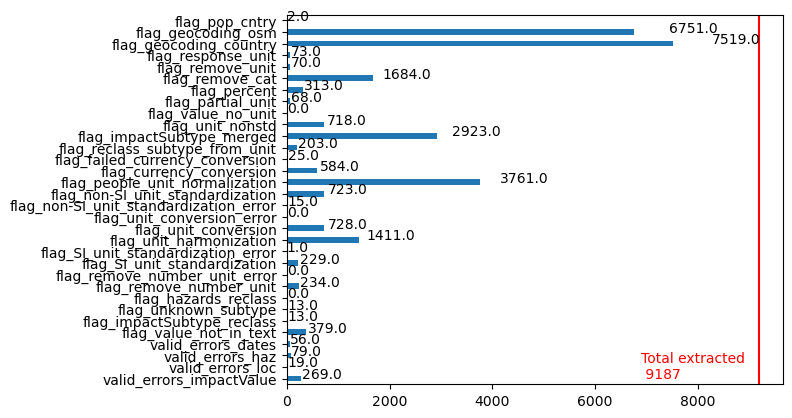

In [9]:
extracted_df["flag_value_not_in_text"] = extracted_df["flag_value_not_in_text"].fillna(0).astype(np.float64)
ax = extracted_df[flag_cols].sum().plot(kind="barh")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

In [33]:
extracted_df[extracted_df.appealCode=="MDRSD034"][["location", "locationPolygon", "country_iso3", "flag_geocoding_osm", "flag_geocoding_country"]]

,location,locationPolygon,country_iso3,flag_geocoding_osm,flag_geocoding_country
9022,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9023,"[Gedaref, Kassala]","[Madeinat Al Gedaref, Madeinat Kassala, Reifi ...",[SDN],1.0,0.0
9024,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9025,"[Abu Hamad, Abu Sara, Atbara, Gederef, Gold lo...","[Abu Hamad, Agig, Blue Nile, Blue Nile, Easter...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",2.0,2.0
9026,[],[Sudan],[SDN],0.0,1.0
9027,"[Blue Nile, Gadarief, Gazira, Khartoum, North ...","[Blue Nile, Blue Nile, Eastern, Khartoum, Khar...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",1.0,1.0
9028,"[Central Darfur, East Darfur, Gedaref, Kassala...","[Blue Nile, Central Darfur, East Darfur, Madei...",[SDN],2.0,0.0
9029,"[Aqaba, Atbara-Abu Hamad Road, Dongola-Halfa R...","[Agig, Blue Nile, Northern, Port Sudan, Red Se...",[SDN],1.0,4.0
9030,"[Aqaba, Egypt, Jebeit, Port Sudan, Sudan, Tokar]","[Agig, Blue Nile, Egypt, Port Sudan, River Nil...","[EGY, SDN]",1.0,3.0
9031,[Arba’at Dam],[Sudan],[SDN],0.0,1.0


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99603/3303138969.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors


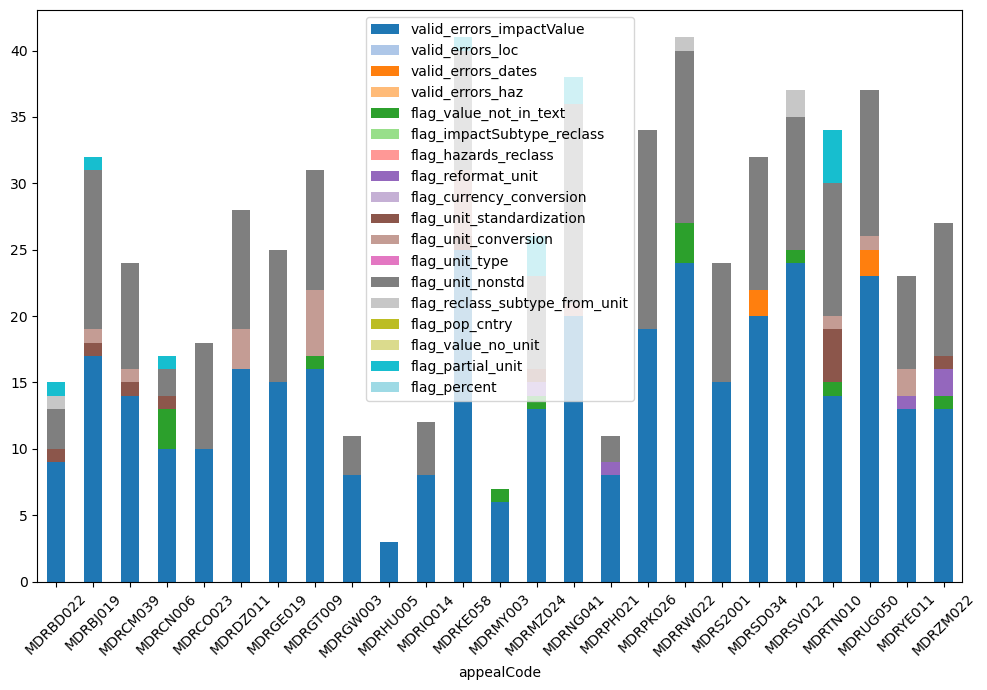

In [23]:
from fileinput import filename
import matplotlib.cm as cm
# Number of unique flag columns
num_flags = len(flag_cols)

# Generate N unique colors from a colormap (e.g., 'tab20', 'viridis', 'nipy_spectral', etc.)
cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors
colors = [cmap(i) for i in range(num_flags)]

# Make the plot
fig, ax = plt.subplots(1,1, figsize=(10, 7))
extracted_df.groupby("appealCode")[flag_cols].sum().plot(
    kind="bar",
    ax=ax,
    rot=45,
    stacked=True,
    color=colors  # assign unique colors
)

plt.tight_layout()
fig.savefig(DATA_FIGURE / f"flags_{res_savename_ext}.png", bbox_inches="tight", dpi=300)

In [45]:
extracted_df.groupby("appealCode")[flag_cols].sum()

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
appealCode,,,,,,,,,,,,,,
MDRBD022,0,0,0,0,0,1,1,0,7,1,0,0,0,0
MDRBJ019,0,0,0,0,0,2,0,0,10,0,0,0,2,0
MDRCM039,0,0,0,0,0,1,0,0,8,0,0,0,0,0
MDRCN006,0,0,0,0,0,1,0,0,1,0,0,0,1,0
MDRCO023,0,0,0,0,0,0,0,0,10,0,0,0,0,0
MDRDZ011,0,0,0,0,0,0,3,0,11,0,0,0,0,0
MDRGE019,0,0,0,0,0,0,0,0,13,0,0,0,0,0
MDRGT009,0,0,0,0,0,0,5,0,3,0,0,0,1,0
MDRGW003,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [46]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemic, Conflict]",False
25,"[Flood, Epidemic]",False
26,[Flood],False
27,"[Flood, Epidemic, Conflict]",False
28,"[Flood, Epidemic, Conflict]",False
29,"[Flood, Epidemic]",False
30,"[Flood, Conflict, Epidemic]",False
31,[Flood],False
32,"[Conflict, Flood, Epidemic]",False
33,[Flood],False
